# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [44]:
STUDENT_NAME = "Trần Chí Nhân"  # TODO: Họ và tên
STUDENT_ID = "2510176"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Trần Chí Nhân (2510176)


In [45]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: \\wsl.localhost\Ubuntu\home\nhan\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [46]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [47]:
# TODO N1
# shifted_logits = ...
# exp_logits = ...
# class_probabilities = ...
# predicted_classes = ...
# confidence_scores = ...
shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)

In [48]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [49]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [50]:
# TODO N2
# train_feature_mean = ...
# train_feature_std = ...
# X_train_scaled = ...
# X_val_scaled = ...
train_feature_mean = np.mean(X_train, axis=0)
train_feature_std = np.std(X_train, axis=0)

X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [51]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [52]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [53]:
# TODO N3
# correct_mask = ...
# high_confidence_mask = ...
# review_mask = ...
# review_indices = ...
correct_mask = predicted_classes == true_labels
high_confidence_mask = confidence_scores >= confidence_threshold

# Cần review nếu dự đoán sai HOẶC confidence thấp
review_mask = ~(correct_mask & high_confidence_mask) 
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [54]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [55]:
# TODO N4
# normalized_batch = ...
# augmented_batch = ...
# augmented_batch[0, 0, 0, 0] = ...
# Flip ngang (chiều Width là chiều thứ 3, tức axis=2 do layout B,H,W,C)
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = np.flip(normalized_batch, axis=2).copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

Mỗi dòng đại diện cho một mẫu xe trong bộ dữ liệu 1985 Auto Imports.  

Các giá trị thiếu trong tệp automobile_raw.csv được ký hiệu bằng dấu ?.

symboling là mức đánh giá rủi ro bảo hiểm của xe, với thang giá trị từ -3 đến 3. 

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [56]:
# TODO D1
# raw_df = ...
# raw_shape = ...
# raw_missing_marker_count = ...
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum().sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [57]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [58]:
# TODO D2
# df_clean = ...
# for column in NUMERIC_COLUMNS:
#     ...
# missing_by_column = ...
df_clean = raw_df.replace('?', np.nan).copy()

for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])

missing_by_column = df_clean.isna().sum()

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->

Không nên fill tất cả numeric columns bằng một giá trị (như 0) vì mỗi cột là một đại lượng đo lường khác nhau (chiều dài, mã lực, giá...). Việc gán chung một giá trị sẽ làm hỏng phân phối thống kê và gây nhiễu nghiêm trọng cho từng đặc trưng.

Với price, lựa chọn drop phù hợp hơn. Giá xe thường là biến mục tiêu trong các mô hình dự đoán. Việc tự ý fill giá trị cho biến mục tiêu sẽ đánh lừa mô hình và đưa ra insight sai lệch trong quá trình EDA.

Cột normalized_losses bị thiếu 41 giá trị (khoảng 20% dữ liệu). Sự thiếu hụt quá lớn này làm giảm đáng kể độ tin cậy của cột; nếu giữ lại để phân tích, nó sẽ thu hẹp số lượng mẫu khả dụng xuống mức rủi ro.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [59]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [60]:
# TODO D3
# analysis_df = ...
# X_auto = ...
# auto_feature_mean = ...
# auto_feature_std = ...
# X_auto_scaled = ...
analysis_df = df_clean.dropna(subset=AUTO_FEATURES).copy()
X_auto = analysis_df[AUTO_FEATURES].to_numpy(dtype=np.float64)

auto_feature_mean = np.mean(X_auto, axis=0)
auto_feature_std = np.std(X_auto, axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [61]:
# TODO D4
# price_index = ...
# price_z = ...
# price_outlier_mask = ...
# price_outliers = ...
price_index = AUTO_FEATURES.index('price')
price_z = X_auto_scaled[:, price_index]
price_outlier_mask = np.abs(price_z) > 2
price_outliers = analysis_df[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [62]:
# TODO D5
# engine_price_corr = ...
# price_by_body_style = ...
engine_index = AUTO_FEATURES.index('engine_size')
price_index = AUTO_FEATURES.index('price')

# np.corrcoef trả về ma trận 2x2, lấy giá trị ở [0, 1]
engine_price_corr = np.corrcoef(X_auto[:, engine_index], X_auto[:, price_index])[0, 1]
price_by_body_style = analysis_df.groupby('body_style')['price'].mean().sort_index()

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

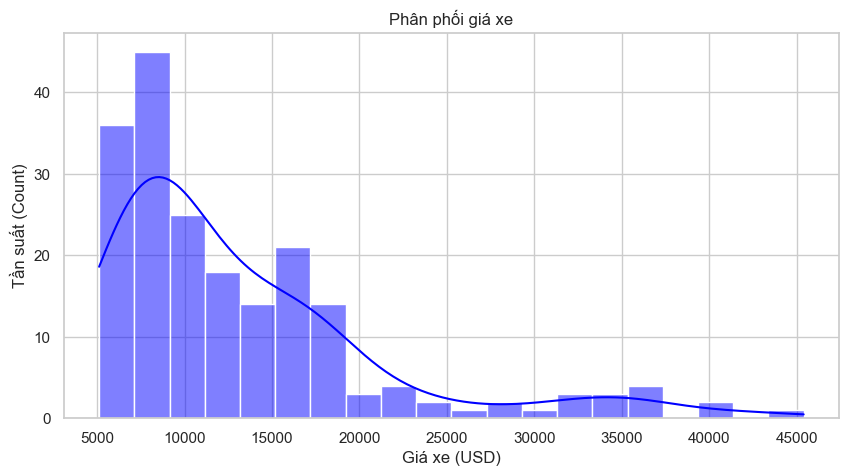

In [63]:
# TODO M2.1: histogram/KDE của price
plt.figure(figsize=(10, 5))
sns.histplot(data=analysis_df, x='price', kde=True, color='blue', bins=20)
plt.title('Phân phối giá xe')
plt.xlabel('Giá xe (USD)')
plt.ylabel('Tần suất (Count)')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Nhận xét: Phân phối của giá xe bị lệch phải. Phần lớn các mẫu xe có mức giá tập trung ở phân khúc bình dân (dưới 15,000 USD), trong khi một số ít xe sang kéo dài phần đuôi đồ thị sang mức giá rất cao (trên 30,000 USD).

## M2.2 Dataset có cân bằng theo body style không?

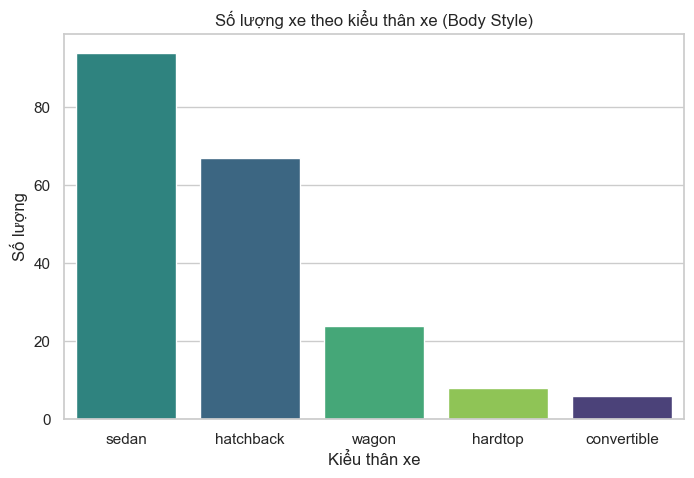

In [64]:
# TODO M2.2: countplot của body_style
plt.figure(figsize=(8, 5))
sns.countplot(data=analysis_df, x='body_style', hue = 'body_style', order=analysis_df['body_style'].value_counts().index, palette='viridis')
plt.title('Số lượng xe theo kiểu thân xe (Body Style)')
plt.xlabel('Kiểu thân xe')
plt.ylabel('Số lượng')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Nhận xét: Dữ liệu mất cân bằng khá rõ rệt giữa các kiểu thân xe. Sedan và hatchback là hai nhóm phổ biến nhất, chiếm đa số dòng xe, trong khi các kiểu xe như convertible hoặc hardtop lại có số lượng mẫu rất ít.

## M2.3 Price khác nhau theo body style ra sao?

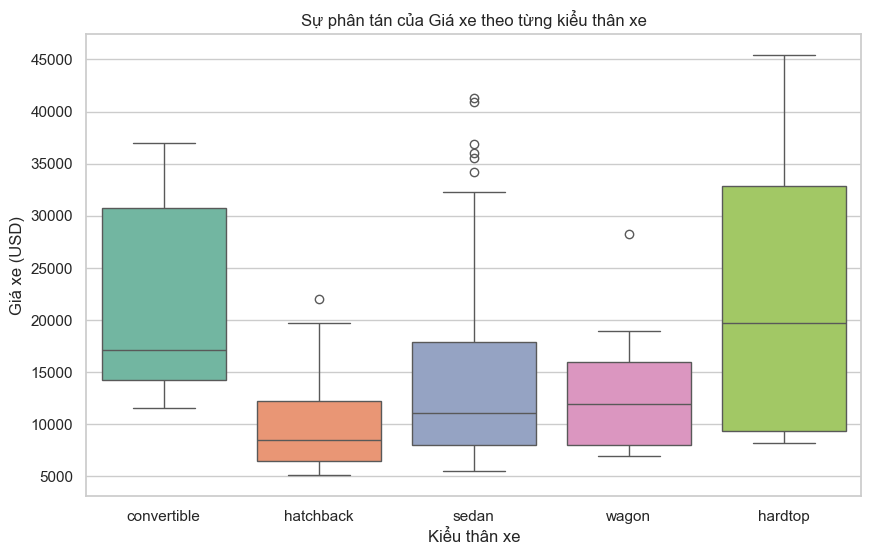

In [65]:
# TODO M2.3: boxplot price theo body_style
plt.figure(figsize=(10, 6))
sns.boxplot(data=analysis_df, x='body_style', hue = 'body_style', y='price', palette='Set2')
plt.title('Sự phân tán của Giá xe theo từng kiểu thân xe')
plt.xlabel('Kiểu thân xe')
plt.ylabel('Giá xe (USD)')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Nhận xét: Xe hardtop và convertible có mức giá trung vị cao nhất và sự phân tán giá cũng rộng, cho thấy đây là phân khúc xe đắt tiền. Ngược lại, hatchback có mức giá trung bình thấp nhất, định vị rõ là phân khúc xe giá rẻ, phổ thông.

## M2.4 Engine size liên quan thế nào tới price?

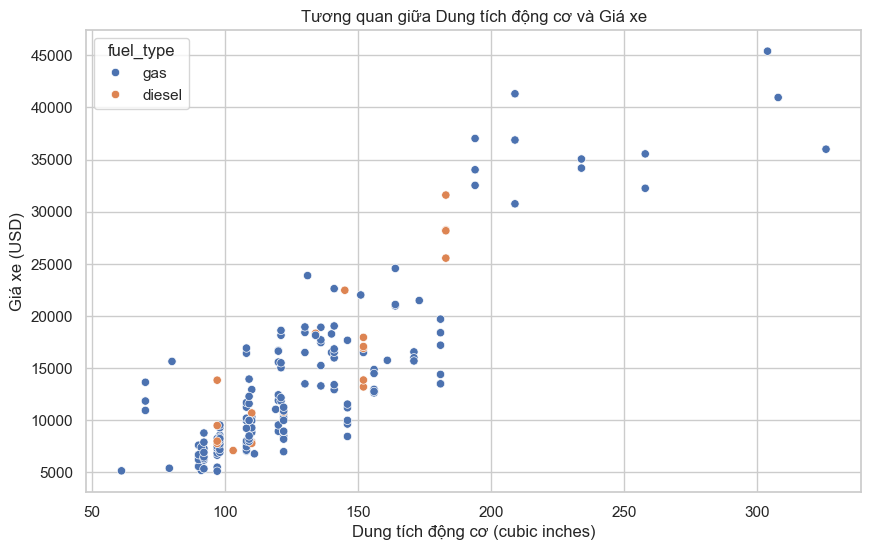

In [66]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
plt.figure(figsize=(10, 6))
sns.scatterplot(data=analysis_df, x='engine_size', y='price', hue='fuel_type')
plt.title('Tương quan giữa Dung tích động cơ và Giá xe')
plt.xlabel('Dung tích động cơ (cubic inches)')
plt.ylabel('Giá xe (USD)')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Nhận xét: Biểu đồ thể hiện mối tương quan thuận tuyến tính mạnh mẽ: dung tích động cơ càng lớn, giá xe càng cao. Các xe chạy nhiên liệu gas chiếm đa số và trải dải ở nhiều mức giá, trong khi xe diesel phân tán tập trung ở phân khúc giá trung bình-thấp.

## M2.5 Các feature numeric tương quan ra sao?

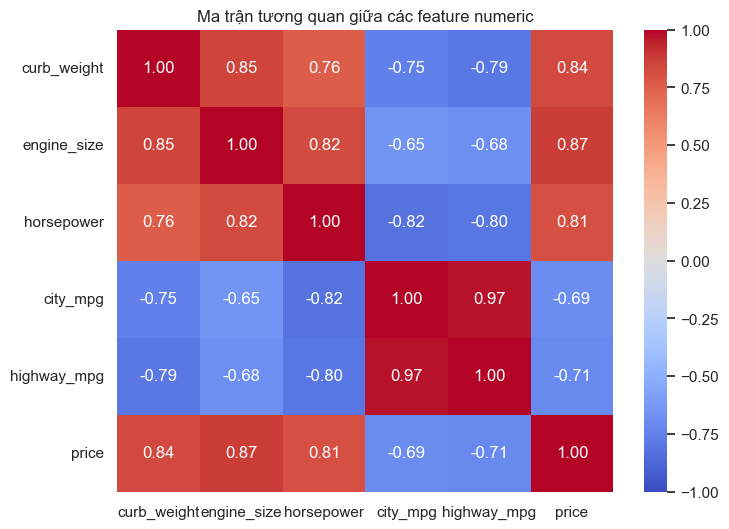

In [67]:
# TODO M2.5: correlation heatmap
plt.figure(figsize=(8, 6))
corr_matrix = analysis_df[AUTO_FEATURES].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Ma trận tương quan giữa các feature numeric')
plt.show()


**Nhận xét:** <!-- 1--2 câu -->

Nhận xét: price có tương quan thuận cực kỳ mạnh với engine_size và horsepower (cùng mức tăng kích thước động cơ/sức mạnh thì giá đắt hơn). Ngược lại, mức tiêu thụ nhiên liệu (city_mpg và highway_mpg) có tương quan nghịch mạnh với giá xe: xe càng đắt thường tốn nhiều nhiên liệu hơn.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

Câu hỏi phân tích: Công suất động cơ (Horsepower) tác động thế nào đến sự hao tốn nhiên liệu (Highway MPG)?

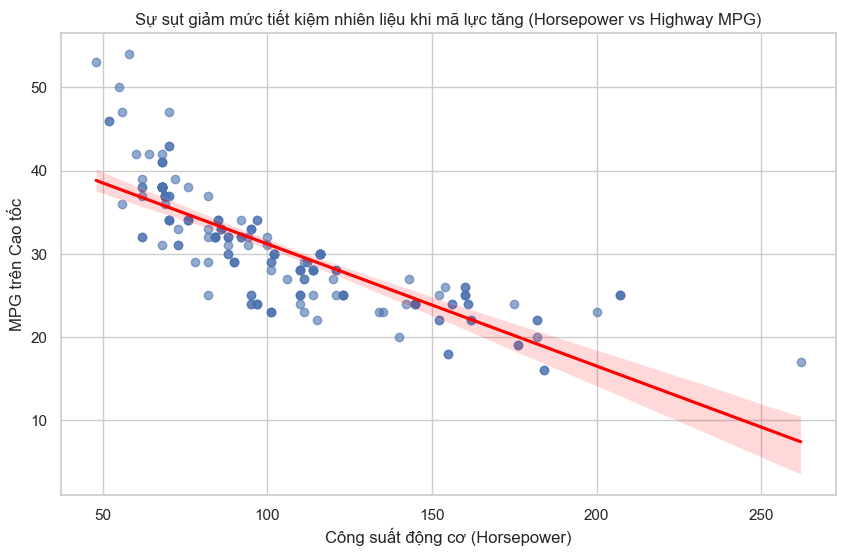

In [68]:
# TODO M2.6: biểu đồ tự chọn
plt.figure(figsize=(10, 6))
sns.regplot(data=analysis_df, x='horsepower', y='highway_mpg', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Sự sụt giảm mức tiết kiệm nhiên liệu khi mã lực tăng (Horsepower vs Highway MPG)')
plt.xlabel('Công suất động cơ (Horsepower)')
plt.ylabel('MPG trên Cao tốc')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

Nhận xét: Đồ thị đường hồi quy xác nhận mối quan hệ nghịch biến rất rõ ràng. Để đánh đổi lấy sức mạnh động cơ (horsepower cao), chiếc xe bắt buộc phải tiêu thụ nhiều nhiên liệu hơn (chỉ số MPG tụt giảm mạnh).

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

Phát hiện chính:

* Phân phối của giá xe (Price) không đồng đều mà lệch phải (right-skewed), cho thấy thị trường năm 1985 tập trung chủ yếu vào nhóm xe phổ thông có giá rẻ, còn phân khúc hạng sang là thiểu số.

* Dung tích động cơ (engine_size) và mã lực (horsepower) là các yếu tố có sức ảnh hưởng mạnh nhất đến giá trị của một chiếc xe (tương quan thuận r > 0.8).

* Người dùng phải đánh đổi tính kinh tế nhiên liệu để đổi lấy sức mạnh: xe có công suất càng mạnh thì mức highway_mpg càng thấp.

Hạn chế của dataset:

1. Số lượng mẫu khá nhỏ (hơn 200 dòng), điều này có thể dẫn tới việc mô hình Machine Learning sau này dễ bị overfitting hoặc chưa đủ đại diện cho toàn bộ quy luật thị trường.

2. Việc thiếu hụt tới 20% dữ liệu ở cột normalized_losses khiến đại lượng này không thể khai thác tối đa và nếu cố ép sử dụng sẽ gây nhiễu thông tin.

Correlation không đồng nghĩa Causation:

Mặc dù có tương quan mạnh giữa kiểu thân xe mui trần (convertible) với mức giá đắt đỏ, nhưng bản thân thiết kế thân xe không là nguyên nhân duy nhất gây ra giá cao. Thực chất, do các nhà sản xuất xe sang (chi phí cơ bản đã đắt) có xu hướng sản xuất loại xe mui trần và trang bị động cơ lớn, nên hai yếu tố này đồng biến cùng nhau.

Câu hỏi phân tích tiếp theo:

Liệu có thể sử dụng tỷ số nén (compression_ratio) kết hợp với engine_size để dự báo sự chênh lệch giá thành giữa các loại nhiên liệu gas và diesel không?